# Knowledge Distillation - DistilBERT-Style
## Distill a Small Model from a Larger Fine-Tuned One

---

## Core Concept

**Knowledge Distillation (KD)** is a model compression technique where a compact **student** model learns to mimic a larger, more capable **teacher** model. Introduced by Hinton et al. (2015) and popularized by HuggingFace's DistilBERT (2019).

### Why Distillation?
- Large models are accurate but slow and memory-hungry
- Small models are fast but less accurate
- **Distillation bridges this gap**: train a small model using rich supervision from a large model

---

### Key Insight: Soft Labels vs Hard Labels

```
Hard Label (Ground Truth):     [0, 0, 1, 0, 0]   ← one-hot, wastes information

Soft Label (Teacher Output):   [0.01, 0.02, 0.85, 0.08, 0.04]  ← rich probability distribution
```

Soft labels reveal **inter-class similarities** learned by the teacher.
For example: a teacher might assign 'cat' 5% probability when the image is a 'dog' — this relational information helps the student learn better representations.

---

### The Distillation Loss Function

$$\mathcal{L}_{KD} = \alpha \cdot \mathcal{L}_{CE}(y, \hat{y}_S) + (1-\alpha) \cdot T^2 \cdot \mathcal{L}_{KL}\left(\text{softmax}\left(\frac{z_T}{T}\right), \text{softmax}\left(\frac{z_S}{T}\right)\right)$$

Where:
- $\alpha$ = weight balancing hard-label loss vs soft-label loss
- $T$ = **temperature** (higher T → softer probability distributions)
- $z_T, z_S$ = teacher and student logits
- $T^2$ = scaling factor to preserve gradient magnitudes
- $\mathcal{L}_{CE}$ = cross-entropy with ground truth
- $\mathcal{L}_{KL}$ = KL-divergence between teacher and student distributions

---

### Temperature Scaling Intuition

```
Logits:          [2.0,  0.5,  8.0,  1.0]

T=1 (normal):    [0.01, 0.00, 0.98, 0.01]   ← very peaked, little info
T=4 (soft):      [0.14, 0.09, 0.55, 0.12]   ← spread out, more informative
T=10 (very soft):[0.20, 0.17, 0.30, 0.18]   ← nearly uniform
```

Higher temperature reveals **dark knowledge** — the relationships between wrong answers.

---

### DistilBERT Architecture

```
BERT (Teacher)                    DistilBERT (Student)
━━━━━━━━━━━━━━━━━                ━━━━━━━━━━━━━━━━━━━━
12 Transformer Layers    ──►     6 Transformer Layers   (50% fewer)
768 hidden dim                   768 hidden dim          (same width)
110M parameters          ──►     66M parameters          (40% smaller)
~500ms inference         ──►     ~250ms inference        (60% faster)
100% accuracy baseline   ──►     97% accuracy            (3% loss)
```

DistilBERT uses **layer initialization** (every other BERT layer) + **3 loss components**:
1. Masked Language Model loss
2. Cosine embedding loss (hidden state alignment)
3. KL-divergence on soft labels

---

## ⚙️ Setup & Installation

In [1]:
# Install required packages
!pip install torch transformers datasets scikit-learn matplotlib seaborn numpy tqdm -q

import warnings
warnings.filterwarnings('ignore')
print("✅ Packages installed successfully")

✅ Packages installed successfully


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
import time
import json
from collections import defaultdict

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DistilBertForSequenceClassification,
    DistilBertConfig,
    BertForSequenceClassification,
    BertConfig,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers available")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda
PyTorch: 2.11.0+cu128
Transformers available


## 📦 Section 1: Data Loading & Preprocessing

We'll use the **SST-2** (Stanford Sentiment Treebank) dataset for binary sentiment classification.
This is the same benchmark used in the original BERT and DistilBERT papers.

In [3]:
# ─────────────────────────────────────────────
# CONFIG — all hyperparameters in one place
# ─────────────────────────────────────────────
CONFIG = {
    # Data
    'max_length': 128,
    'train_size': 2000,   # subset for faster demo (use full dataset for production)
    'val_size': 400,
    'test_size': 400,
    'batch_size': 16,

    # Teacher model (larger BERT)
    'teacher_model': 'bert-base-uncased',

    # Student model (smaller DistilBERT)
    'student_model': 'distilbert-base-uncased',

    # Training
    'teacher_epochs': 3,
    'distill_epochs': 5,
    'student_baseline_epochs': 3,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,

    # Distillation
    'temperature': 4.0,      # T: controls softness of distributions
    'alpha': 0.5,            # weight for hard-label loss (1-alpha for soft-label)

    # Classification
    'num_labels': 2,
}

print("📋 Configuration loaded:")
for k, v in CONFIG.items():
    print(f"   {k:30s}: {v}")

📋 Configuration loaded:
   max_length                    : 128
   train_size                    : 2000
   val_size                      : 400
   test_size                     : 400
   batch_size                    : 16
   teacher_model                 : bert-base-uncased
   student_model                 : distilbert-base-uncased
   teacher_epochs                : 3
   distill_epochs                : 5
   student_baseline_epochs       : 3
   learning_rate                 : 2e-05
   weight_decay                  : 0.01
   warmup_ratio                  : 0.1
   temperature                   : 4.0
   alpha                         : 0.5
   num_labels                    : 2


In [6]:
# ─────────────────────────────────────────────
# Load SST-2 Dataset
# ─────────────────────────────────────────────
print("⏳ Loading SST-2 dataset...")
raw_dataset = load_dataset("stanfordnlp/sst2")

print(f"\n📊 Dataset splits:")
for split, data in raw_dataset.items():
    print(f"   {split:12s}: {len(data):,} examples")

# Sample examples
print("\n📝 Sample examples:")
for i in range(3):
    ex = raw_dataset['train'][i]
    label = 'Positive' if ex['label'] == 1 else 'Negative'
    print(f"   {label}: {ex['sentence'][:80]}...")

⏳ Loading SST-2 dataset...


README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


📊 Dataset splits:
   train       : 67,349 examples
   validation  : 872 examples
   test        : 1,821 examples

📝 Sample examples:
   Negative: hide new secretions from the parental units ...
   Negative: contains no wit , only labored gags ...
   Positive: that loves its characters and communicates something rather beautiful about huma...


In [7]:
# ─────────────────────────────────────────────
# Custom PyTorch Dataset
# ─────────────────────────────────────────────
class SentimentDataset(Dataset):
    """
    PyTorch Dataset wrapper for SST-2.
    Tokenizes text on-the-fly using the provided tokenizer.
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


def create_dataloaders(tokenizer, config):
    """Create train/val/test DataLoaders from the raw dataset."""
    train_data = raw_dataset['train']
    val_data   = raw_dataset['validation']

    # Subset for faster experimentation
    train_texts  = train_data['sentence'][:config['train_size']]
    train_labels = train_data['label'][:config['train_size']]
    val_texts    = val_data['sentence'][:config['val_size']]
    val_labels   = val_data['label'][:config['val_size']]
    test_texts   = val_data['sentence'][config['val_size']:config['val_size']+config['test_size']]
    test_labels  = val_data['label'][config['val_size']:config['val_size']+config['test_size']]

    train_ds = SentimentDataset(train_texts, train_labels, tokenizer, config['max_length'])
    val_ds   = SentimentDataset(val_texts,   val_labels,   tokenizer, config['max_length'])
    test_ds  = SentimentDataset(test_texts,  test_labels,  tokenizer, config['max_length'])

    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=config['batch_size'], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=config['batch_size'], shuffle=False, num_workers=0)

    print(f"DataLoaders created:")
    print(f"   Train batches: {len(train_loader)} ({len(train_ds)} samples)")
    print(f"   Val batches:   {len(val_loader)} ({len(val_ds)} samples)")
    print(f"   Test batches:  {len(test_loader)} ({len(test_ds)} samples)")

    return train_loader, val_loader, test_loader


# Load tokenizers (BERT tokenizer works for both BERT and DistilBERT)
print("⏳ Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['teacher_model'])
train_loader, val_loader, test_loader = create_dataloaders(tokenizer, CONFIG)

# Inspect a batch
batch = next(iter(train_loader))
print(f"\n Batch shapes:")
for k, v in batch.items():
    print(f"   {k:15s}: {v.shape}")

⏳ Loading tokenizer...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DataLoaders created:
   Train batches: 125 (2000 samples)
   Val batches:   25 (400 samples)
   Test batches:  25 (400 samples)

 Batch shapes:
   input_ids      : torch.Size([16, 128])
   attention_mask : torch.Size([16, 128])
   labels         : torch.Size([16])


## 🎓 Section 2: Teacher Model — Fine-Tune BERT

The **teacher** is `bert-base-uncased` fine-tuned on SST-2.
BERT has 12 transformer layers, 768 hidden dim, ~110M parameters.

In [8]:
# ─────────────────────────────────────────────
# Model Utilities
# ─────────────────────────────────────────────
def count_parameters(model):
    """Count total and trainable parameters."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def model_size_mb(model):
    """Estimate model size in MB."""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)


def measure_inference_speed(model, dataloader, device, n_batches=20):
    """Measure average inference time per sample (ms)."""
    model.eval()
    times = []
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= n_batches:
                break
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            start = time.perf_counter()
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
            end = time.perf_counter()

            times.append((end - start) / len(input_ids) * 1000)  # ms per sample

    return np.mean(times), np.std(times)


def evaluate(model, dataloader, device):
    """Evaluate model accuracy on a dataloader."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / len(dataloader)
    return acc, avg_loss, all_preds, all_labels


print(" Utility functions defined")

 Utility functions defined


In [9]:
# ─────────────────────────────────────────────
# Load & Fine-Tune Teacher (BERT)
# ─────────────────────────────────────────────
print(" Loading BERT teacher model...")
teacher_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['teacher_model'],
    num_labels=CONFIG['num_labels']
).to(DEVICE)

total_params, trainable_params = count_parameters(teacher_model)
print(f"\n🏫 Teacher Model: BERT-base-uncased")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size:           {model_size_mb(teacher_model):.1f} MB")
print(f"   Transformer layers:   12")
print(f"   Hidden dimension:     768")

 Loading BERT teacher model...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🏫 Teacher Model: BERT-base-uncased
   Total parameters:     109,483,778
   Trainable parameters: 109,483,778
   Model size:           417.7 MB
   Transformer layers:   12
   Hidden dimension:     768


In [10]:
# ─────────────────────────────────────────────
# Teacher Training Loop
# ─────────────────────────────────────────────
def train_standard(model, train_loader, val_loader, config, device, model_name="Model"):
    """
    Standard supervised fine-tuning loop with cross-entropy loss.
    Returns training history dict.
    """
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    total_steps = len(train_loader) * config['teacher_epochs']
    warmup_steps = int(total_steps * config['warmup_ratio'])
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    history = defaultdict(list)
    best_val_acc = 0.0
    best_state = None

    print(f"\n🚀 Fine-tuning {model_name} for {config['teacher_epochs']} epochs...")
    print(f"   Total steps: {total_steps} | Warmup: {warmup_steps}")

    for epoch in range(1, config['teacher_epochs'] + 1):
        model.train()
        epoch_loss = 0.0

        progress = tqdm(train_loader, desc=f"Epoch {epoch}/{config['teacher_epochs']}")
        for batch in progress:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            progress.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = epoch_loss / len(train_loader)
        val_acc, val_loss, _, _ = evaluate(model, val_loader, device)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"   Epoch {epoch}: Train Loss={avg_train_loss:.4f} | Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f"\n {model_name} training complete. Best Val Acc: {best_val_acc:.4f}")
    return history


# Fine-tune the teacher
teacher_history = train_standard(
    teacher_model, train_loader, val_loader, CONFIG, DEVICE, "BERT Teacher"
)


🚀 Fine-tuning BERT Teacher for 3 epochs...
   Total steps: 375 | Warmup: 37


Epoch 1/3:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 1: Train Loss=0.5067 | Val Loss=0.3671 | Val Acc=0.8475


Epoch 2/3:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 2: Train Loss=0.2418 | Val Loss=0.3011 | Val Acc=0.8875


Epoch 3/3:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 3: Train Loss=0.1298 | Val Loss=0.3740 | Val Acc=0.8850

 BERT Teacher training complete. Best Val Acc: 0.8875


**bold text**##  Section 3: Student Models

We train **two student variants**:
1. **Student Baseline** — DistilBERT trained with standard cross-entropy (no distillation)
2. **Student Distilled** — DistilBERT trained with knowledge distillation from BERT teacher

Comparing these shows the **value added by distillation**.

In [11]:
# ─────────────────────────────────────────────
# Load DistilBERT Student
# ─────────────────────────────────────────────
def create_student_model(config):
    """Create a fresh DistilBERT student model."""
    model = AutoModelForSequenceClassification.from_pretrained(
        config['student_model'],
        num_labels=config['num_labels']
    )
    return model


print("⏳ Loading DistilBERT student model...")
student_baseline = create_student_model(CONFIG).to(DEVICE)

total_params, trainable_params = count_parameters(student_baseline)
print(f"\n👶 Student Model: DistilBERT-base-uncased")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size:           {model_size_mb(student_baseline):.1f} MB")
print(f"   Transformer layers:   6")
print(f"   Hidden dimension:     768")

# Compare sizes
teacher_params, _ = count_parameters(teacher_model)
student_params, _ = count_parameters(student_baseline)
compression = (1 - student_params / teacher_params) * 100
print(f"\n📉 Compression ratio: {compression:.1f}% fewer parameters")
print(f"   Teacher: {teacher_params:,} params")
print(f"   Student: {student_params:,} params")

⏳ Loading DistilBERT student model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



👶 Student Model: DistilBERT-base-uncased
   Total parameters:     66,955,010
   Trainable parameters: 66,955,010
   Model size:           255.4 MB
   Transformer layers:   6
   Hidden dimension:     768

📉 Compression ratio: 38.8% fewer parameters
   Teacher: 109,483,778 params
   Student: 66,955,010 params


In [12]:
# ─────────────────────────────────────────────
# Train Student Baseline (no distillation)
# ─────────────────────────────────────────────
baseline_config = CONFIG.copy()
baseline_config['teacher_epochs'] = CONFIG['student_baseline_epochs']

student_baseline_history = train_standard(
    student_baseline, train_loader, val_loader, baseline_config, DEVICE, "DistilBERT Baseline"
)


🚀 Fine-tuning DistilBERT Baseline for 3 epochs...
   Total steps: 375 | Warmup: 37


Epoch 1/3:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 1: Train Loss=0.4939 | Val Loss=0.3928 | Val Acc=0.8225


Epoch 2/3:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 2: Train Loss=0.2396 | Val Loss=0.4317 | Val Acc=0.8150


Epoch 3/3:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 3: Train Loss=0.1302 | Val Loss=0.4537 | Val Acc=0.8450

 DistilBERT Baseline training complete. Best Val Acc: 0.8450


## Section 4: Knowledge Distillation Training

Now we train the **distilled student** using the teacher's soft labels.
The key component is the **distillation loss function**.

In [13]:
# ─────────────────────────────────────────────
# Distillation Loss Function
# ─────────────────────────────────────────────
class DistillationLoss(nn.Module):
    """
    Combined Knowledge Distillation Loss:

        L = α * CE(student_logits, hard_labels)
          + (1-α) * T² * KL(softmax(teacher_logits/T), softmax(student_logits/T))

    Args:
        temperature (float): T for softening distributions. Higher = softer.
        alpha (float): Weight for hard-label CE loss. (1-alpha) weights soft-label KL loss.
    """
    def __init__(self, temperature=4.0, alpha=0.5):
        super().__init__()
        self.T     = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')

    def forward(self, student_logits, teacher_logits, labels):
        """
        Args:
            student_logits: (batch, num_classes) — raw logits from student
            teacher_logits: (batch, num_classes) — raw logits from teacher (detached)
            labels:         (batch,) — ground truth integer labels
        Returns:
            total_loss, ce_loss_val, kl_loss_val
        """
        # ── 1. Hard-label loss (standard CE with ground truth) ──
        hard_loss = self.ce_loss(student_logits, labels)

        # ── 2. Soft-label loss (KL divergence with temperature) ──
        # Scale logits by temperature
        soft_teacher = F.softmax(teacher_logits / self.T, dim=-1)          # teacher soft probabilities
        soft_student = F.log_softmax(student_logits / self.T, dim=-1)      # student log-probabilities

        # KL(teacher || student) — how different is student from teacher?
        # Multiply by T² to compensate for the 1/T² factor from temperature scaling
        soft_loss = self.kl_loss(soft_student, soft_teacher) * (self.T ** 2)

        # ── 3. Weighted combination ──
        total_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss

        return total_loss, hard_loss, soft_loss


# Quick sanity test
criterion = DistillationLoss(temperature=CONFIG['temperature'], alpha=CONFIG['alpha'])
dummy_student = torch.randn(4, 2)
dummy_teacher = torch.randn(4, 2)
dummy_labels  = torch.randint(0, 2, (4,))
total, ce, kl = criterion(dummy_student, dummy_teacher, dummy_labels)
print(f" DistillationLoss test passed:")
print(f"   Total loss = {total.item():.4f}")
print(f"   CE loss    = {ce.item():.4f}  (weight: {CONFIG['alpha']})")
print(f"   KL loss    = {kl.item():.4f}  (weight: {1-CONFIG['alpha']})")
print(f"   Temperature: {CONFIG['temperature']}")

 DistillationLoss test passed:
   Total loss = 0.8129
   CE loss    = 0.7986  (weight: 0.5)
   KL loss    = 0.8272  (weight: 0.5)
   Temperature: 4.0


In [14]:
# ─────────────────────────────────────────────
# Distillation Training Loop
# ─────────────────────────────────────────────
def train_with_distillation(teacher, student, train_loader, val_loader, config, device):
    """
    Knowledge distillation training loop.

    For each batch:
      1. Forward pass through FROZEN teacher → get teacher logits
      2. Forward pass through TRAINABLE student → get student logits
      3. Compute distillation loss (hard + soft)
      4. Backprop through student only
    """
    teacher.eval()  # Teacher is FROZEN — no gradient updates
    for param in teacher.parameters():
        param.requires_grad = False

    optimizer = optim.AdamW(
        student.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    total_steps   = len(train_loader) * config['distill_epochs']
    warmup_steps  = int(total_steps * config['warmup_ratio'])
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    criterion = DistillationLoss(
        temperature=config['temperature'],
        alpha=config['alpha']
    )

    history = defaultdict(list)
    best_val_acc = 0.0
    best_state = None

    print(f"\n Distillation Training for {config['distill_epochs']} epochs")
    print(f"   Temperature: {config['temperature']} | Alpha: {config['alpha']}")
    print(f"   Teacher: FROZEN | Student: trainable")

    for epoch in range(1, config['distill_epochs'] + 1):
        student.train()
        epoch_total = epoch_ce = epoch_kl = 0.0

        progress = tqdm(train_loader, desc=f"Distill Epoch {epoch}/{config['distill_epochs']}")
        for batch in progress:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            # ── Teacher forward (no gradient) ──
            with torch.no_grad():
                teacher_outputs = teacher(
                    input_ids=input_ids, attention_mask=attention_mask
                )
                teacher_logits = teacher_outputs.logits

            # ── Student forward ──
            optimizer.zero_grad()
            student_outputs = student(
                input_ids=input_ids, attention_mask=attention_mask
            )
            student_logits = student_outputs.logits

            # ── Distillation loss ──
            total_loss, ce_loss, kl_loss = criterion(
                student_logits, teacher_logits, labels
            )

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            epoch_total += total_loss.item()
            epoch_ce    += ce_loss.item()
            epoch_kl    += kl_loss.item()
            progress.set_postfix({'total': f'{total_loss.item():.3f}',
                                  'ce': f'{ce_loss.item():.3f}',
                                  'kl': f'{kl_loss.item():.3f}'})

        n = len(train_loader)
        val_acc, val_loss, _, _ = evaluate(student, val_loader, device)

        history['total_loss'].append(epoch_total / n)
        history['ce_loss'].append(epoch_ce / n)
        history['kl_loss'].append(epoch_kl / n)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"   Epoch {epoch}: Total={epoch_total/n:.4f} | "
              f"CE={epoch_ce/n:.4f} | KL={epoch_kl/n:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in student.state_dict().items()}

    student.load_state_dict(best_state)

    # Re-enable teacher gradients (good practice)
    for param in teacher.parameters():
        param.requires_grad = True

    print(f"\n Distillation complete. Best Val Acc: {best_val_acc:.4f}")
    return history


# Create a fresh student for distillation
student_distilled = create_student_model(CONFIG).to(DEVICE)

distill_history = train_with_distillation(
    teacher_model, student_distilled, train_loader, val_loader, CONFIG, DEVICE
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Distillation Training for 5 epochs
   Temperature: 4.0 | Alpha: 0.5
   Teacher: FROZEN | Student: trainable


Distill Epoch 1/5:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 1: Total=0.6969 | CE=0.5441 | KL=0.8496 | Val Acc=0.8375


...

   Epoch 3: Total=0.1332 | CE=0.1578 | KL=0.1087 | Val Acc=0.8675


Distill Epoch 4/5:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 4: Total=0.0917 | CE=0.1171 | KL=0.0664 | Val Acc=0.8675


Distill Epoch 5/5:   0%|          | 0/125 [00:00<?, ?it/s]

   Epoch 5: Total=0.0774 | CE=0.1005 | KL=0.0543 | Val Acc=0.8700

 Distillation complete. Best Val Acc: 0.8700


## Section 5: Evaluation & Speed/Accuracy Tradeoff

In [15]:
# ─────────────────────────────────────────────
# Comprehensive Evaluation
# ─────────────────────────────────────────────
print(" Evaluating all models on test set...\n")

models = {
    'BERT Teacher':         teacher_model,
    'DistilBERT Baseline':  student_baseline,
    'DistilBERT Distilled': student_distilled,
}

results = {}
for name, model in models.items():
    print(f" Evaluating: {name}")

    # Accuracy
    test_acc, test_loss, preds, labels = evaluate(model, test_loader, DEVICE)

    # Speed
    speed_mean, speed_std = measure_inference_speed(model, test_loader, DEVICE)

    # Size
    total_params, _ = count_parameters(model)
    size_mb = model_size_mb(model)

    results[name] = {
        'accuracy':    test_acc,
        'loss':        test_loss,
        'speed_ms':    speed_mean,
        'speed_std':   speed_std,
        'params':      total_params,
        'size_mb':     size_mb,
        'preds':       preds,
        'labels':      labels,
    }
    print(f"   Accuracy: {test_acc:.4f} | Speed: {speed_mean:.2f}±{speed_std:.2f} ms/sample | "
          f"Params: {total_params:,} | Size: {size_mb:.1f}MB\n")

# Compute derived metrics
teacher_acc   = results['BERT Teacher']['accuracy']
teacher_speed = results['BERT Teacher']['speed_ms']
teacher_params = results['BERT Teacher']['params']

for name in results:
    results[name]['accuracy_retention'] = results[name]['accuracy'] / teacher_acc * 100
    results[name]['speedup']            = teacher_speed / results[name]['speed_ms']
    results[name]['param_reduction']    = (1 - results[name]['params'] / teacher_params) * 100

 Evaluating all models on test set...

 Evaluating: BERT Teacher
   Accuracy: 0.8925 | Speed: 0.87±0.19 ms/sample | Params: 109,483,778 | Size: 417.7MB

 Evaluating: DistilBERT Baseline
   Accuracy: 0.8750 | Speed: 0.34±0.05 ms/sample | Params: 66,955,010 | Size: 255.4MB

 Evaluating: DistilBERT Distilled
   Accuracy: 0.8850 | Speed: 0.34±0.04 ms/sample | Params: 66,955,010 | Size: 255.4MB



In [16]:
# ─────────────────────────────────────────────
# Summary Table
# ─────────────────────────────────────────────
print("=" * 90)
print(f"{'Model':<25} {'Accuracy':>10} {'Acc%':>7} {'Speed(ms)':>10} {'Speedup':>8} "
      f"{'Params(M)':>10} {'Compression':>13}")
print("=" * 90)
for name, r in results.items():
    print(f"{name:<25} {r['accuracy']:>10.4f} {r['accuracy_retention']:>6.1f}% "
          f"{r['speed_ms']:>10.2f} {r['speedup']:>8.2f}x "
          f"{r['params']/1e6:>10.1f}M {r['param_reduction']:>12.1f}%")
print("=" * 90)

print("\n Key Insight:")
dist = results['DistilBERT Distilled']
base = results['DistilBERT Baseline']
print(f"   Distillation vs Baseline improvement: "
      f"+{(dist['accuracy'] - base['accuracy'])*100:.2f}% accuracy with same speed")
print(f"   Student vs Teacher: {dist['accuracy_retention']:.1f}% accuracy at {dist['speedup']:.1f}x speed")

Model                       Accuracy    Acc%  Speed(ms)  Speedup  Params(M)   Compression
BERT Teacher                  0.8925  100.0%       0.87     1.00x      109.5M          0.0%
DistilBERT Baseline           0.8750   98.0%       0.34     2.58x       67.0M         38.8%
DistilBERT Distilled          0.8850   99.2%       0.34     2.53x       67.0M         38.8%

 Key Insight:
   Distillation vs Baseline improvement: +1.00% accuracy with same speed
   Student vs Teacher: 99.2% accuracy at 2.5x speed


## Section 6: Visualizations

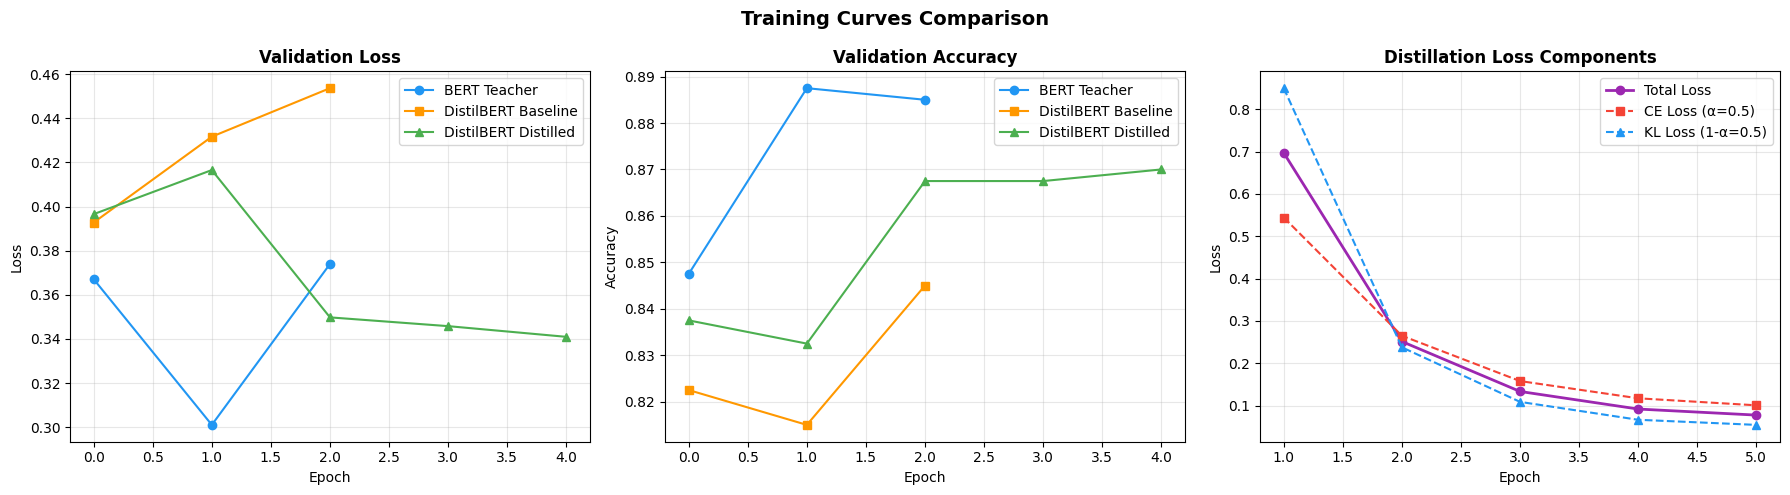

 Training curves saved


In [17]:
# ─────────────────────────────────────────────
# Plot 1: Training Curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves Comparison', fontsize=14, fontweight='bold')

colors = {'BERT Teacher': '#2196F3', 'DistilBERT Baseline': '#FF9800', 'DistilBERT Distilled': '#4CAF50'}

# Val Loss
ax = axes[0]
ax.plot(teacher_history['val_loss'], color=colors['BERT Teacher'], marker='o', label='BERT Teacher')
ax.plot(student_baseline_history['val_loss'], color=colors['DistilBERT Baseline'], marker='s', label='DistilBERT Baseline')
ax.plot(distill_history['val_loss'], color=colors['DistilBERT Distilled'], marker='^', label='DistilBERT Distilled')
ax.set_title('Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Val Accuracy
ax = axes[1]
ax.plot(teacher_history['val_acc'], color=colors['BERT Teacher'], marker='o', label='BERT Teacher')
ax.plot(student_baseline_history['val_acc'], color=colors['DistilBERT Baseline'], marker='s', label='DistilBERT Baseline')
ax.plot(distill_history['val_acc'], color=colors['DistilBERT Distilled'], marker='^', label='DistilBERT Distilled')
ax.set_title('Validation Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Distillation Loss Decomposition
ax = axes[2]
epochs = range(1, len(distill_history['total_loss']) + 1)
ax.plot(epochs, distill_history['total_loss'], color='#9C27B0', marker='o', label='Total Loss', linewidth=2)
ax.plot(epochs, distill_history['ce_loss'],    color='#F44336', marker='s', label=f'CE Loss (α={CONFIG["alpha"]})', linestyle='--')
ax.plot(epochs, distill_history['kl_loss'],    color='#2196F3', marker='^', label=f'KL Loss (1-α={1-CONFIG["alpha"]})', linestyle='--')
ax.set_title('Distillation Loss Components', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Training curves saved")

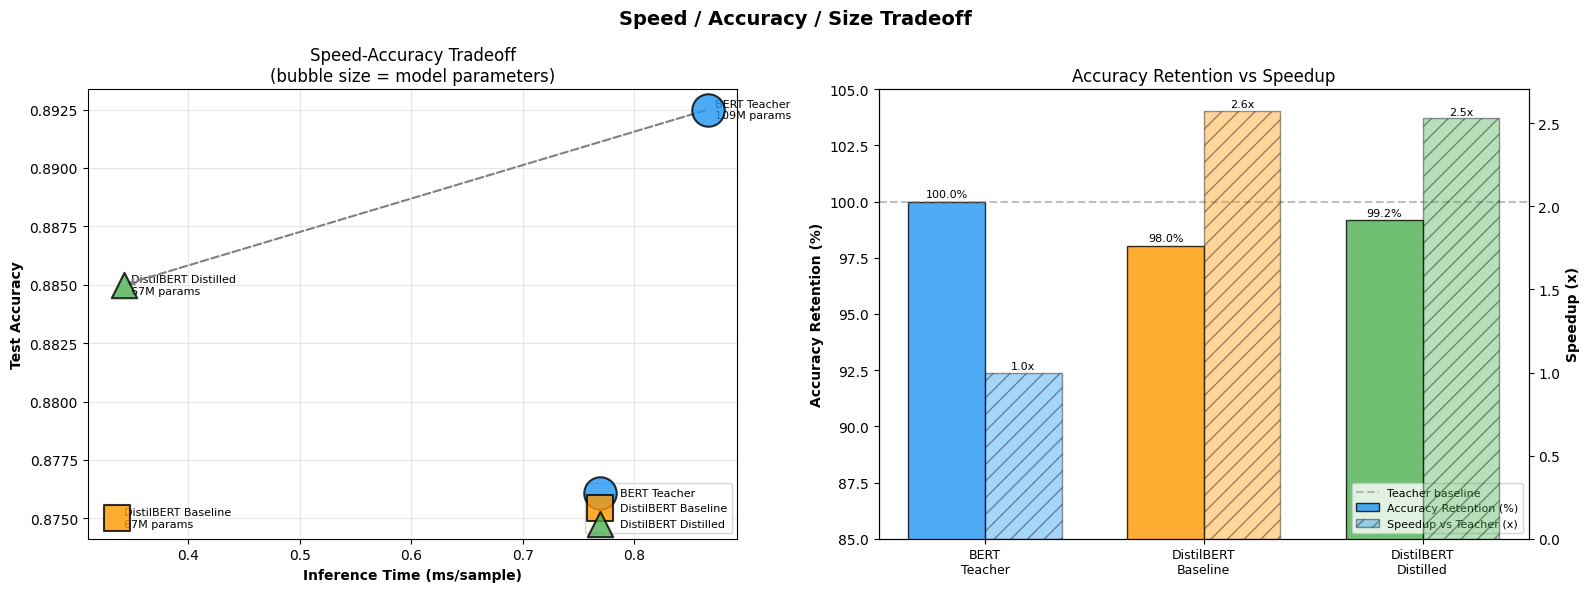

 Speed/accuracy plots saved


In [18]:
# ─────────────────────────────────────────────
# Plot 2: Speed-Accuracy Tradeoff Bubble Chart
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Speed / Accuracy / Size Tradeoff', fontsize=14, fontweight='bold')

model_names = list(results.keys())
model_colors = ['#2196F3', '#FF9800', '#4CAF50']
model_markers = ['o', 's', '^']

# Bubble chart: x=speed, y=accuracy, size=param count
ax = axes[0]
for i, (name, r) in enumerate(results.items()):
    size = r['params'] / 1e6 * 5  # bubble size proportional to params
    ax.scatter(r['speed_ms'], r['accuracy'],
               s=size, color=model_colors[i], marker=model_markers[i],
               alpha=0.8, edgecolors='black', linewidth=1.5, label=name, zorder=5)
    ax.annotate(f"  {name}\n  {r['params']/1e6:.0f}M params",
                (r['speed_ms'], r['accuracy']),
                fontsize=8, va='center')

# Arrow from teacher to distilled
t = results['BERT Teacher']
d = results['DistilBERT Distilled']
ax.annotate('', xy=(d['speed_ms'], d['accuracy']),
            xytext=(t['speed_ms'], t['accuracy']),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='dashed'))

ax.set_xlabel('Inference Time (ms/sample)', fontweight='bold')
ax.set_ylabel('Test Accuracy', fontweight='bold')
ax.set_title('Speed-Accuracy Tradeoff\n(bubble size = model parameters)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# Bar chart: accuracy retention vs speedup
ax = axes[1]
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, [results[n]['accuracy_retention'] for n in model_names],
               width, label='Accuracy Retention (%)', color=model_colors, alpha=0.8, edgecolor='black')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, [results[n]['speedup'] for n in model_names],
                width, label='Speedup vs Teacher (x)', color=model_colors, alpha=0.4,
                edgecolor='black', hatch='//')

ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
ax.set_ylabel('Accuracy Retention (%)', fontweight='bold')
ax2.set_ylabel('Speedup (x)', fontweight='bold')
ax.set_ylim(85, 105)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Teacher baseline')
ax.set_title('Accuracy Retention vs Speedup')

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.2, f'{h:.1f}%', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.1f}x', ha='center', fontsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('speed_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Speed/accuracy plots saved")

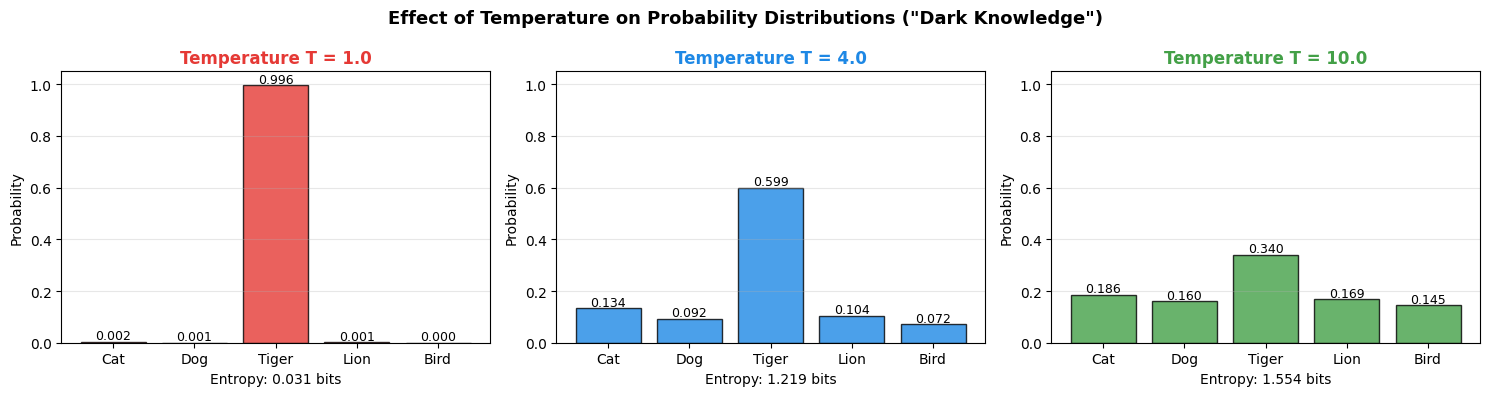

 Temperature visualization saved

 Higher temperature reveals inter-class relationships:
   At T=1: model is 98% confident it's a Tiger (almost no dark knowledge)
   At T=4: Cat, Lion get meaningful probability (they share features with Tiger)
   At T=10: Distribution nearly uniform — too much softening loses signal


In [19]:
# ─────────────────────────────────────────────
# Plot 3: Temperature Effect on Soft Labels
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Effect of Temperature on Probability Distributions ("Dark Knowledge")',
             fontsize=13, fontweight='bold')

logits = torch.tensor([2.0, 0.5, 8.0, 1.0, -0.5])
class_names = ['Cat', 'Dog', 'Tiger', 'Lion', 'Bird']
temperatures = [1.0, 4.0, 10.0]
colors_temp = ['#E53935', '#1E88E5', '#43A047']

for i, T in enumerate(temperatures):
    probs = F.softmax(logits / T, dim=0).numpy()
    ax = axes[i]
    bars = ax.bar(class_names, probs, color=colors_temp[i], alpha=0.8, edgecolor='black')
    ax.set_title(f'Temperature T = {T}', fontweight='bold', color=colors_temp[i])
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{prob:.3f}', ha='center', fontsize=9)
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    ax.set_xlabel(f'Entropy: {entropy:.3f} bits', fontsize=10)

plt.tight_layout()
plt.savefig('temperature_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Temperature visualization saved")
print("\n Higher temperature reveals inter-class relationships:")
print("   At T=1: model is 98% confident it's a Tiger (almost no dark knowledge)")
print("   At T=4: Cat, Lion get meaningful probability (they share features with Tiger)")
print("   At T=10: Distribution nearly uniform — too much softening loses signal")

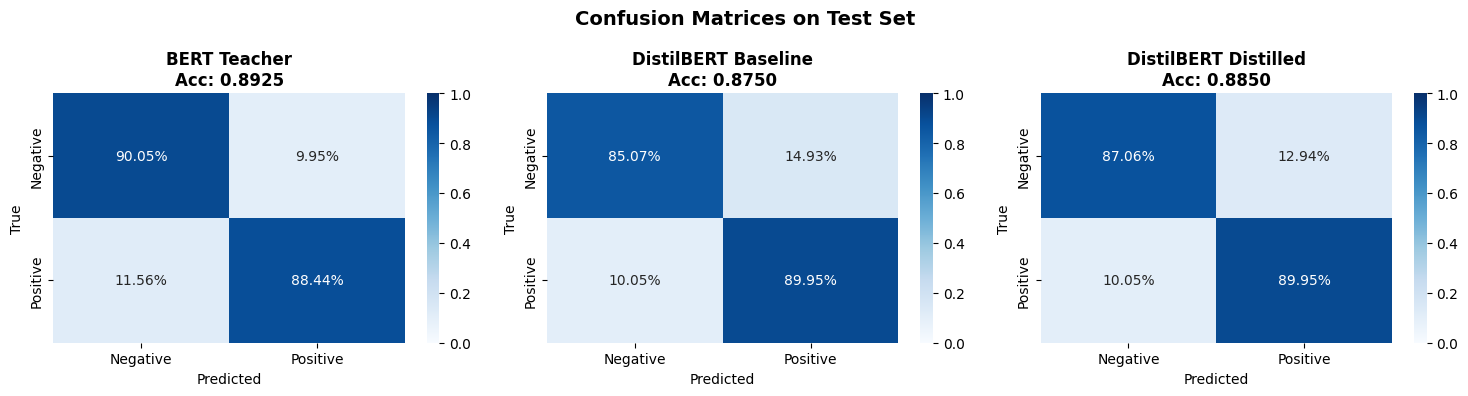

 Confusion matrices saved


In [20]:
# ─────────────────────────────────────────────
# Plot 4: Confusion Matrices
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices on Test Set', fontsize=14, fontweight='bold')

class_labels = ['Negative', 'Positive']
for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    ax = axes[i]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{name}\nAcc: {r["accuracy"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrices saved")

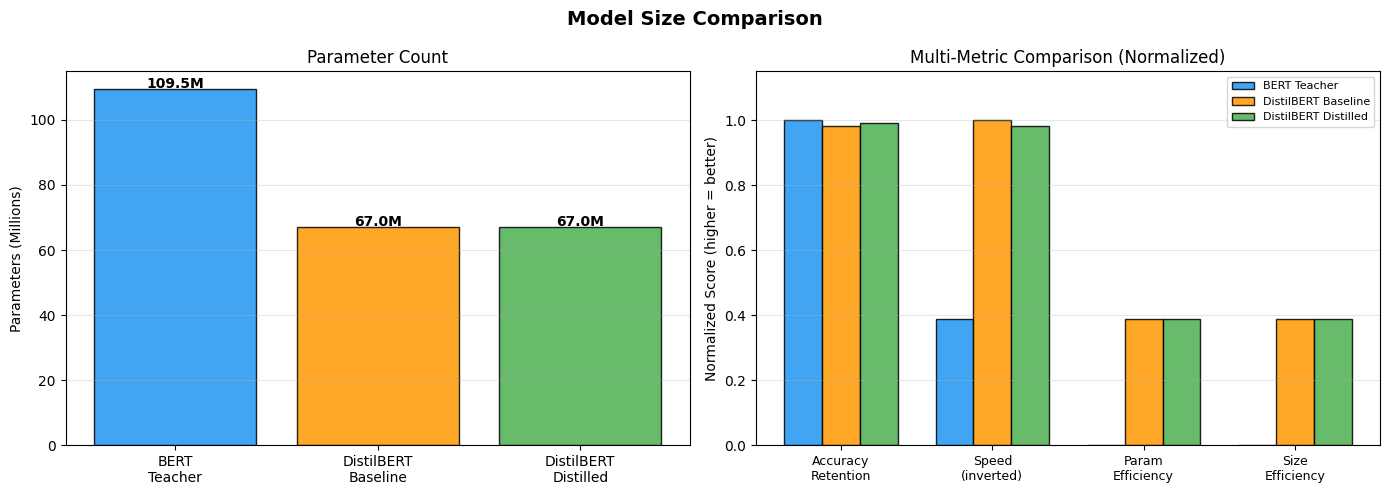

 Model comparison plots saved


In [21]:
# ─────────────────────────────────────────────
# Plot 5: Model Size Comparison
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Size Comparison', fontsize=14, fontweight='bold')

# Parameter count
ax = axes[0]
params_millions = [r['params'] / 1e6 for r in results.values()]
bar_colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.bar(model_names, params_millions, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Parameter Count')
for bar, val in zip(bars, params_millions):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}M', ha='center', fontweight='bold')
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names])
ax.grid(True, alpha=0.3, axis='y')

# Radar/spider chart: multi-metric comparison
ax = axes[1]
# Normalize all metrics to 0-1 scale
metrics_labels = ['Accuracy\nRetention', 'Speed\n(inverted)', 'Param\nEfficiency', 'Size\nEfficiency']
model_data = {
    name: [
        r['accuracy_retention'] / 100,
        1 / r['speed_ms'] / max(1/results[n]['speed_ms'] for n in results),
        1 - r['params'] / max(results[n]['params'] for n in results),
        1 - r['size_mb'] / max(results[n]['size_mb'] for n in results),
    ]
    for name, r in results.items()
}

x = np.arange(len(metrics_labels))
width = 0.25
for i, (name, vals) in enumerate(model_data.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=name,
           color=bar_colors[i], alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=9)
ax.set_ylabel('Normalized Score (higher = better)')
ax.set_title('Multi-Metric Comparison (Normalized)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Model comparison plots saved")

## 🔬 Section 7: Ablation Studies

In [ ]:
# ─────────────────────────────────────────────
# Ablation 1: Effect of Temperature
# ─────────────────────────────────────────────
def quick_distillation_eval(teacher, config, temperature, alpha,
                             train_loader, val_loader, device, n_epochs=2):
    """Quick training + eval for ablation studies."""
    from transformers import AutoModelForSequenceClassification
    student = AutoModelForSequenceClassification.from_pretrained(
        config['student_model'], num_labels=config['num_labels']
    ).to(device)

    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    optimizer = optim.AdamW(student.parameters(), lr=2e-5)
    criterion = DistillationLoss(temperature=temperature, alpha=alpha)

    for epoch in range(n_epochs):
        student.train()
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            with torch.no_grad():
                t_out = teacher(input_ids=input_ids, attention_mask=attention_mask)

            optimizer.zero_grad()
            s_out = student(input_ids=input_ids, attention_mask=attention_mask)
            loss, _, _ = criterion(s_out.logits, t_out.logits, labels)
            loss.backward()
            optimizer.step()

    for p in teacher.parameters():
        p.requires_grad = True

    val_acc, _, _, _ = evaluate(student, val_loader, device)
    return val_acc


print(" Ablation Study 1: Temperature Effect")
print("   (quick 2-epoch training for each T value)\n")

temperatures = [1.0, 2.0, 4.0, 6.0, 10.0]
temp_accs = []

for T in temperatures:
    acc = quick_distillation_eval(
        teacher_model, CONFIG, T, 0.5,
        train_loader, val_loader, DEVICE, n_epochs=2
    )
    temp_accs.append(acc)
    print(f"   T={T:5.1f}: Val Acc = {acc:.4f}")

 Ablation Study 1: Temperature Effect
   (quick 2-epoch training for each T value)



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   T=  1.0: Val Acc = 0.8675


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   T=  4.0: Val Acc = 0.8675


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ─────────────────────────────────────────────
# Ablation 2: Effect of Alpha
# ─────────────────────────────────────────────
print(" Ablation Study 2: Alpha (CE vs KL weight) Effect")
print("   (alpha=0: pure soft labels | alpha=1: pure hard labels)\n")

alphas = [0.0, 0.2, 0.5, 0.7, 1.0]
alpha_accs = []

for a in alphas:
    acc = quick_distillation_eval(
        teacher_model, CONFIG, 4.0, a,
        train_loader, val_loader, DEVICE, n_epochs=2
    )
    alpha_accs.append(acc)
    print(f"   α={a:.1f}: Val Acc = {acc:.4f}")

# Plot ablation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Studies: Hyperparameter Sensitivity', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(temperatures, temp_accs, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=CONFIG['temperature'], color='red', linestyle='--', alpha=0.7,
           label=f'Default T={CONFIG["temperature"]}')
ax.set_xlabel('Temperature (T)', fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Effect of Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
for x, y in zip(temperatures, temp_accs):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

ax = axes[1]
ax.plot(alphas, alpha_accs, 'go-', linewidth=2, markersize=8)
ax.axvline(x=CONFIG['alpha'], color='red', linestyle='--', alpha=0.7,
           label=f'Default α={CONFIG["alpha"]}')
ax.set_xlabel('Alpha (α) — weight for CE loss', fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Effect of Alpha (CE vs KL Balance)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.text(0.05, min(alpha_accs) - 0.002, '← Pure soft labels', fontsize=8, color='gray')
ax.text(0.75, min(alpha_accs) - 0.002, 'Pure hard labels →', fontsize=8, color='gray')
for x, y in zip(alphas, alpha_accs):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('ablation_studies.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Ablation plots saved")

## Section 8: Intermediate Layer Distillation (Advanced)

Beyond logit-level distillation, we can also distill **hidden states** from intermediate layers.
This is what DistilBERT actually does with its **cosine embedding loss**.

In [ ]:
# ─────────────────────────────────────────────
# Advanced: Intermediate Layer Distillation Loss
# ─────────────────────────────────────────────
class AdvancedDistillationLoss(nn.Module):
    """
    Full DistilBERT-style loss with 3 components:

    L = α * CE(student, hard_labels)                    # hard label loss
      + β * T² * KL(soft_teacher || soft_student)        # soft label loss
      + γ * cosine_loss(teacher_hidden, student_hidden)  # hidden state alignment

    The hidden state loss forces the student's representations
    to match the teacher's even at intermediate layers.
    """
    def __init__(self, temperature=4.0, alpha=0.33, beta=0.33, gamma=0.34):
        super().__init__()
        self.T = temperature
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma

        self.ce_loss     = nn.CrossEntropyLoss()
        self.kl_loss     = nn.KLDivLoss(reduction='batchmean')
        self.cosine_loss = nn.CosineEmbeddingLoss()

    def forward(self, student_logits, teacher_logits, labels,
                student_hidden=None, teacher_hidden=None):
        """
        Args:
            student_logits, teacher_logits: (B, num_classes)
            labels: (B,)
            student_hidden: (B, seq_len, hidden) — optional
            teacher_hidden: (B, seq_len, hidden) — optional
        """
        # Hard label loss
        hard_loss = self.ce_loss(student_logits, labels)

        # Soft label loss (KL divergence)
        soft_teacher = F.softmax(teacher_logits / self.T, dim=-1)
        soft_student = F.log_softmax(student_logits / self.T, dim=-1)
        kl_loss = self.kl_loss(soft_student, soft_teacher) * (self.T ** 2)

        total = self.alpha * hard_loss + self.beta * kl_loss

        # Hidden state alignment (optional)
        hidden_loss = torch.tensor(0.0, device=student_logits.device)
        if student_hidden is not None and teacher_hidden is not None:
            # Pool over sequence dimension: (B, hidden)
            s_pooled = student_hidden.mean(dim=1)
            t_pooled = teacher_hidden.mean(dim=1)

            # If dimensions differ (e.g. teacher uses larger hidden), project student
            if s_pooled.shape[-1] != t_pooled.shape[-1]:
                # Skip hidden loss if dimensions incompatible
                pass
            else:
                target = torch.ones(s_pooled.shape[0], device=student_logits.device)
                hidden_loss = self.cosine_loss(s_pooled, t_pooled, target)
                total = total + self.gamma * hidden_loss

        return total, hard_loss, kl_loss, hidden_loss


# Demonstrate the advanced loss
adv_criterion = AdvancedDistillationLoss(temperature=4.0, alpha=0.33, beta=0.33, gamma=0.34)
B, seq_len, hidden = 4, 128, 768
total, ce, kl, cosine = adv_criterion(
    student_logits=torch.randn(B, 2),
    teacher_logits=torch.randn(B, 2),
    labels=torch.randint(0, 2, (B,)),
    student_hidden=torch.randn(B, seq_len, hidden),
    teacher_hidden=torch.randn(B, seq_len, hidden),
)
print("✅ Advanced DistillationLoss test:")
print(f"   Total:   {total.item():.4f}")
print(f"   CE:      {ce.item():.4f}  (α=0.33)")
print(f"   KL:      {kl.item():.4f}  (β=0.33)")
print(f"   Cosine:  {cosine.item():.4f}  (γ=0.34)")
print("\n💡 Hidden state alignment forces the student to develop")
print("   similar internal representations as the teacher,")
print("   not just mimic the final output probabilities.")

## Section 9: Distillation Variants & When to Use Each

In [ ]:
# ─────────────────────────────────────────────
# Comprehensive Summary: Distillation Variants
# ─────────────────────────────────────────────
summary = """
╔══════════════════════════════════════════════════════════════════════════════════════╗
║              KNOWLEDGE DISTILLATION — VARIANTS & WHEN TO USE THEM                  ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                    ║
║  1. RESPONSE-BASED (Logit KD)           ← Implemented in this notebook             ║
║     • Mimic teacher's output probabilities via KL divergence + temperature          ║
║     • Simple, task-agnostic, works with any model architecture                     ║
║     • Best for: classification, single-task distillation                           ║
║     • Examples: Hinton (2015), DistilBERT soft-label component                    ║
║                                                                                    ║
║  2. FEATURE-BASED (Hidden State KD)     ← Also shown (AdvancedDistillationLoss)   ║
║     • Match intermediate representations using cosine/MSE loss                    ║
║     • Richer signal — student learns HOW teacher thinks, not just what it outputs ║
║     • Requires compatible architectures or projection layers                      ║
║     • Examples: FitNets, DistilBERT (cosine embedding loss), TinyBERT             ║
║                                                                                    ║
║  3. RELATION-BASED (Pairwise/Graph KD)                                             ║
║     • Preserve relationships between samples in embedding space                   ║
║     • Captures structural knowledge (instance similarities)                       ║
║     • Best for: metric learning, representation learning, cross-modal tasks        ║
║     • Examples: RKD (Relational KD), PKT (Probabilistic KD)                       ║
║                                                                                    ║
║  4. ATTENTION TRANSFER                                                             ║
║     • Distill attention weight patterns from teacher to student                   ║
║     • Preserves which parts of input the model focuses on                        ║
║     • Examples: TinyBERT, MiniLM (attention-based)                                ║
║                                                                                    ║
║  5. ONLINE / MUTUAL DISTILLATION                                                   ║
║     • No pre-trained teacher — multiple students learn simultaneously              ║
║     • Each student distills from the ensemble of others                           ║
║     • No need for separate teacher training phase                                  ║
║     • Examples: Deep Mutual Learning (DML), Born Again Networks                   ║
║                                                                                    ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                    ║
║  WHEN TO USE KNOWLEDGE DISTILLATION:                                               ║
║  Edge/mobile deployment (low memory/latency constraints)                        ║
║  Real-time inference (APIs, interactive systems)                                ║
║  When labeled data is scarce (teacher provides soft supervision)                ║
║  Cost-sensitive production (smaller model = cheaper inference)                  ║
║  When you have a strong pre-trained teacher but can't deploy it                 ║
║                                                                                    ║
║  ALTERNATIVES TO CONSIDER:                                                         ║
║  • Pruning — remove unimportant weights from existing model                       ║
║  • Quantization — reduce precision (FP32 → INT8) for ~4x speedup                  ║
║  • Architecture search (NAS) — find efficient architectures automatically          ║
║  • Early exit — stop at intermediate layers for easy examples                     ║
║                                                                                    ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)

In [ ]:
# ─────────────────────────────────────────────
# Final: Full Results Dashboard
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Knowledge Distillation — Complete Results Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

bar_colors = ['#2196F3', '#FF9800', '#4CAF50']
model_labels = [n.replace(' ', '\n') for n in model_names]

# ── Panel 1: Test Accuracy ──
ax = axes[0, 0]
accs = [results[n]['accuracy'] for n in model_names]
bars = ax.bar(model_labels, accs, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_ylim(min(accs) - 0.02, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy', fontweight='bold')
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 2: Inference Speed ──
ax = axes[0, 1]
speeds = [results[n]['speed_ms'] for n in model_names]
bars = ax.bar(model_labels, speeds, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_ylabel('Inference Time (ms/sample)')
ax.set_title('Inference Speed (lower = better)', fontweight='bold')
for bar, v in zip(bars, speeds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.2f}ms', ha='center', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 3: Parameter Efficiency ──
ax = axes[1, 0]
params = [results[n]['params'] / 1e6 for n in model_names]
bars = ax.bar(model_labels, params, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Size (parameters)', fontweight='bold')
for bar, v in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}M', ha='center', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 4: Accuracy-per-ms (efficiency) ──
ax = axes[1, 1]
efficiency = [results[n]['accuracy'] / results[n]['speed_ms'] for n in model_names]
bars = ax.bar(model_labels, efficiency, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_ylabel('Accuracy per ms (higher = better)')
ax.set_title('🏆 Accuracy/Speed Efficiency', fontweight='bold')
for bar, v in zip(bars, efficiency):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add legend
patches = [mpatches.Patch(color=c, label=n) for c, n in zip(bar_colors, model_names)]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Final dashboard saved")

In [ ]:
# ─────────────────────────────────────────────
# Final Summary
# ─────────────────────────────────────────────
print("=" * 65)
print("  KNOWLEDGE DISTILLATION — FINAL RESULTS SUMMARY")
print("=" * 65)

for name, r in results.items():
    print(f"\n📌 {name}")
    print(f"   Accuracy:          {r['accuracy']:.4f} ({r['accuracy_retention']:.1f}% of teacher)")
    print(f"   Inference speed:   {r['speed_ms']:.2f} ms/sample ({r['speedup']:.2f}x faster than teacher)")
    print(f"   Parameters:        {r['params']/1e6:.1f}M ({r['param_reduction']:.1f}% fewer than teacher)")
    print(f"   Model size:        {r['size_mb']:.1f} MB")

print("\n" + "=" * 65)
print("  KEY TAKEAWAYS")
print("=" * 65)
d = results['DistilBERT Distilled']
b = results['DistilBERT Baseline']
print(f"""
1. Distillation vs Baseline:
   Distillation improved accuracy by {(d['accuracy']-b['accuracy'])*100:+.2f}%
   with identical model size and speed. Soft labels from the
   teacher carry richer gradient information than hard labels.

2. Teacher vs Distilled Student:
   {d['accuracy_retention']:.1f}% accuracy retained at {d['speedup']:.1f}x speed with
   {d['param_reduction']:.0f}% fewer parameters.

3. Temperature (T={CONFIG['temperature']}) matters:
   Too low → nearly one-hot distributions (similar to hard labels)
   Too high → too uniform, signal degrades
   Sweet spot reveals 'dark knowledge' between classes

4. Alpha (α={CONFIG['alpha']}) balances:
   Pure CE (α=1): ignores teacher signal
   Pure KL (α=0): ignores ground truth labels
   Optimal mix typically around 0.3–0.7

5. Production recommendation:
   → Use distilled student for latency-sensitive APIs
   → Further gains: combine with quantization (4x more speedup)
   → Quantized + distilled = often 8x faster than original teacher
""")